In [19]:
import numpy as np
import matplotlib.pyplot as plt


_dtype = np.float32

here 1
here 1
[   0.75      0.625     0.5       0.375     0.25      0.125     0.
   -0.125    -0.25     -0.375    -0.5      -0.625    -0.75     -0.875
   -1.       -1.125    -1.25     -1.375    -1.5      -1.625    -1.75
   -1.875    -2.       -2.125    -2.25     -2.375    -2.5      -2.625
   -2.75     -2.875    -3.       -3.125    -3.25     -3.375    -3.5
   -3.625    -3.75     -3.875    -4.       -4.125    -4.25     -4.375
   -4.5      -4.625    -4.75     -4.875    -5.       -5.125    -5.25
   -5.375    -5.5      -5.625    -5.75     -5.875    -6.       -6.125
   -6.25     -6.375    -6.5      -6.625    -6.75     -6.875    -7.
   -7.125    -7.25     -7.375    -7.5      -7.625    -7.75     -7.875
   -8.       -8.125    -8.25     -8.375    -8.5      -8.625    -8.75
   -8.875    -9.       -9.125    -9.25     -9.375    -9.5      -9.625
   -9.75     -9.875   -10.      -10.125   -10.25    -10.375   -10.5
  -10.625   -10.75    -10.875   -11.      -11.125   -11.25    -11.375
  -11.5     -11.625

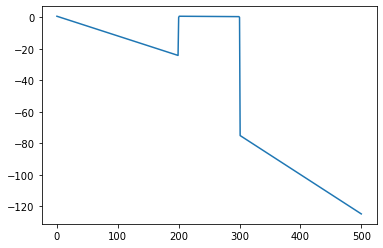

In [39]:


T0 = 1
Tinf = T0/4

Tliq = T0*3/4
Tsol = T0/2

t1 = 200
t2 = 300

Cps = 1
Cpl = 2

Trefroidissement = lambda t, T0, Tinf, Cp, R : Tinf - (T0 -Tinf) * t / Cp / R
Ttransition = lambda t, T1, T2 : (T2 - T1)/ (t2 - t1) * (t - t1) + T1

def T(t, Tinf = 0, T0 = 0, Cpl = 1, Cps = 1, R = 1, Tliq = 0, Tsol = 0) :
    
    mask = t < t1, (t > t1) & (t < t2), t > t2
    
    
    out = np.zeros(t.shape, dtype = _dtype)
    
    for n in range(len(mask)) : 
        if n == 0 : 
            out[mask[n]] += Trefroidissement(t[mask[n]], T0, Tliq, Cpl, R)
        elif n == 1 : 
            out[mask[n]] += Ttransition(t[mask[n]], Tliq, Tsol)
            print("here", n)
        else :
            out[mask[n]] += Trefroidissement(t[mask[n]], Tsol, Tinf, Cps, R)
        
    return out

t = np.linspace(0, 500, num = 501)

plt.plot(t, T(t, Tinf = Tinf, T0 = T0, Tliq = Tliq, Tsol = Tsol, Cpl = Cpl, Cps = Cps))

print(T(t, Tinf = Tinf, T0 = T0, Tliq = Tliq, Tsol = Tsol, Cpl = Cpl))

print(Ttransition(t, Tliq, Tsol))